# SE4 — Results Visualization  
## Interannual trends in river ice phenology

This notebook produces the **Results Visualization** outputs for the river ice phenology analysis. It uses annual GeoTIFF rasters of:

1. **Break-up date** (`breakup_DOHY`)
2. **Freeze-up date** (`freezeup_DOHY`)
3. **Ice duration** (`ice_duration_DAY`)

For each phenological variable, the notebook calculates a pixel-wise interannual trend and produces a mapped figure that tells the data story of spatially variable river ice change.

Note that:
1. **Written visualization instructions** have been documented below in the “Visualization workflow and reproducibility notes” section, including data inputs, trend categories, output directories, and ancillary basin boundary data.
2. This workflow uses **no** external **post-hoc editing**.
3. **Digital figures** (in PNG format) are saved to `FinalProject/analysis_ready/ice_phenology/images` and are also plotted directly in this notebook.
4. **Figure captions** are provided in the “Figure captions” section.

## Visualization workflow and reproducibility notes

### Input data

The notebook expects annual phenology GeoTIFF files in the following folders:

- `FinalProject/analysis_ready/ice_phenology/breakup_DOHY`
- `FinalProject/analysis_ready/ice_phenology/freezeup_DOHY`
- `FinalProject/analysis_ready/ice_phenology/ice_duration_DAY`

The expected filename patterns are:

- `breakup_DOHY_YYYY.tif`
- `freezeup_DOHY_YYYY.tif`
- `ice_duration_DAY_YYYY.tif`

where `YYYY` is the hydrological year.

### Trend estimation

For each pixel, the notebook estimates:

- **Theil–Sen slope** in days per year.
- **Kendall tau p-value**, used here as a Mann–Kendall-style significance test for monotonic change.

The trend class is encoded as:

| Code | Meaning for break-up/freeze-up | Meaning for ice duration |
|---:|---|---|
| -2 | Significant earlier date, p < 0.05 | Significant decrease, p < 0.05 |
| -1 | Earlier date, not significant | Decrease, not significant |
| 0 | No trend or zero slope | No trend or zero slope |
| 1 | Later date, not significant | Increase, not significant |
| 2 | Significant later date, p < 0.05 | Significant increase, p < 0.05 |
| -9999 | Insufficient valid data / no data | Insufficient valid data / no data |

### Ancillary data / basemap

The base map (i.e., basin extent) was provided with a basin boundary shapefile named `ObRiverBasin.shp`, which is located in:
- `FinalProject/raw_data/ObRiverBasin.shp`

The shapefile data can be accessed from **HydroBASINS** dataset, it is reprojected to the raster CRS then.

### Outputs

Trend GeoTIFFs are saved in:

- `FinalProject/analysis_ready/ice_phenology/breakup_trend`
- `FinalProject/analysis_ready/ice_phenology/freezeup_trend`
- `FinalProject/analysis_ready/ice_phenology/ice_duration_trend`

Each trend output folder contains:

- `sen_slope_days_per_year.tif`
- `mk_pvalue.tif`
- `trend_class.tif`

PNG figures are saved in:

- `FinalProject/analysis_ready/ice_phenology/images/breakup_trend.png`
- `FinalProject/analysis_ready/ice_phenology/images/freezeup_trend.png`
- `FinalProject/analysis_ready/ice_phenology/images/ice_duration_trend.png`

In [1]:
# Optional dependency installation
# Run this cell only if the packages are missing in your JupyterLab environment.
#
# !pip install numpy rasterio scipy matplotlib geopandas pillow tqdm

In [2]:
from __future__ import annotations

import math
import os
import re
from dataclasses import dataclass
from glob import glob
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from IPython.display import Image as IPyImage
from IPython.display import Markdown, display
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from PIL import Image
from rasterio.plot import plotting_extent
from scipy.stats import kendalltau, theilslopes
from tqdm.auto import tqdm

# Vector-friendly settings.
# Arial is requested first, but matplotlib will fall back to another available sans-serif font if Arial is unavailable.
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 15,
    "savefig.transparent": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "image.composite_image": False,
})

In [3]:
def find_project_root(project_name: str = "my_research_project") -> Path:
    """Find the FinalProject directory from the current working directory."""
    cwd = Path.cwd().resolve()

    if cwd.name == project_name:
        return cwd

    for parent in [cwd, *cwd.parents]:
        candidate = parent / project_name
        if candidate.exists() and candidate.is_dir():
            return candidate.resolve()

    # Fallback: assume the notebook is already being run from the project root.
    return cwd


PROJECT_ROOT = find_project_root()

ICE_PHENOLOGY_DIR = PROJECT_ROOT / "analysis_ready" / "ice_phenology"

BREAKUP_INPUT_DIR = ICE_PHENOLOGY_DIR / "breakup_DOHY"
FREEZEUP_INPUT_DIR = ICE_PHENOLOGY_DIR / "freezeup_DOHY"
DURATION_INPUT_DIR = ICE_PHENOLOGY_DIR / "ice_duration_DAY"

BREAKUP_TREND_DIR = ICE_PHENOLOGY_DIR / "breakup_trend"
FREEZEUP_TREND_DIR = ICE_PHENOLOGY_DIR / "freezeup_trend"
DURATION_TREND_DIR = ICE_PHENOLOGY_DIR / "ice_duration_trend"

IMAGE_DIR = ICE_PHENOLOGY_DIR / "images"

for folder in [BREAKUP_TREND_DIR, FREEZEUP_TREND_DIR, DURATION_TREND_DIR, IMAGE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Ice phenology directory: {ICE_PHENOLOGY_DIR}")
print(f"Image output directory: {IMAGE_DIR}")

Project root: /home/jovyan/FinalProject
Ice phenology directory: /home/jovyan/FinalProject/analysis_ready/ice_phenology
Image output directory: /home/jovyan/FinalProject/analysis_ready/ice_phenology/images


In [4]:
# Basin boundary shapefile used as an ancillary basemap and clipping boundary.

BASIN_SHP_CANDIDATES = [
    PROJECT_ROOT / "raw_data" / "ObRiverBasin.shp",
]

BASIN_SHP = next((p for p in BASIN_SHP_CANDIDATES if p.exists()), None)

In [5]:
ALPHA = 0.05
MIN_VALID_OBSERVATIONS = 2  # process pixels with at least two-year data are valid.
NODATA_CLASS = -9999

COLOR_BASIN_FILL = "#EEEEEE"
COLOR_BASIN_EDGE = "#DDDDDD"

@dataclass
class PhenologyConfig:
    key: str
    title: str
    input_dir: Path
    trend_dir: Path
    filename_regex: re.Pattern
    image_name: str
    legend_box: List[float]
    colors: Dict[str, str]
    legend_labels: Dict[str, str]
    caption: str


DATASETS = [
    PhenologyConfig(
        key="breakup",
        title="Break-up date trend",
        input_dir=BREAKUP_INPUT_DIR,
        trend_dir=BREAKUP_TREND_DIR,
        filename_regex=re.compile(r"breakup_DOHY_(\d{4})\.tif$", re.IGNORECASE),
        image_name="breakup_trend.png",
        legend_box=[0.7, 0.1, 0.18, 0.15],
        colors={
            "positive_light": "#F1BCD8",
            "positive_dark": "#C51B7D",
            "negative_light": "#ACDB64",
            "negative_dark": "#4D9221",
        },
        legend_labels={
            "positive_light": "Later break-up",
            "negative_light": "Earlier break-up",
            "positive_dark": "Significant later break-up (p<0.05)",
            "negative_dark": "Significant earlier break-up (p<0.05)",
        },
        caption=(
            "Figure 1. Spatial pattern of interannual trends in river ice break-up date. "
            "Green shades indicate earlier break-up, whereas pink shades indicate later break-up. "
            "Darker colors denote statistically significant monotonic trends at p < 0.05."
        ),
    ),
    PhenologyConfig(
        key="freezeup",
        title="Freeze-up date trend",
        input_dir=FREEZEUP_INPUT_DIR,
        trend_dir=FREEZEUP_TREND_DIR,
        filename_regex=re.compile(r"freezeup_DOHY_(\d{4})\.tif$", re.IGNORECASE),
        image_name="freezeup_trend.png",
        legend_box=[0.7, 0.1, 0.18, 0.15],
        colors={
            "positive_light": "#E7C594",
            "positive_dark": "#B35806",
            "negative_light": "#ABB0EC",
            "negative_dark": "#542788",
        },
        legend_labels={
            "positive_light": "Later freeze-up",
            "negative_light": "Earlier freeze-up",
            "positive_dark": "Significant later freeze-up (p<0.05)",
            "negative_dark": "Significant earlier freeze-up (p<0.05)",
        },
        caption=(
            "Figure 2. Spatial pattern of interannual trends in river ice freeze-up date. "
            "Purple shades indicate earlier freeze-up, whereas brown shades indicate later freeze-up. "
            "Darker colors denote statistically significant monotonic trends at p < 0.05."
        ),
    ),
    PhenologyConfig(
        key="ice_duration",
        title="Ice duration trend",
        input_dir=DURATION_INPUT_DIR,
        trend_dir=DURATION_TREND_DIR,
        filename_regex=re.compile(r"ice_duration_DAY_(\d{4})\.tif$", re.IGNORECASE),
        image_name="ice_duration_trend.png",
        legend_box=[0.7, 0.1, 0.18, 0.15],
        colors={
            "positive_light": "#91C8E4",
            "positive_dark": "#3A59D1",
            "negative_light": "#ff8f8f",
            "negative_dark": "#ff0000",
        },
        legend_labels={
            "positive_light": "Increase",
            "negative_light": "Decrease",
            "positive_dark": "Significant increase (p<0.05)",
            "negative_dark": "Significant decrease (p<0.05)",
        },
        caption=(
            "Figure 3. Spatial pattern of interannual trends in river ice duration. "
            "Red shades indicate decreasing ice duration, whereas blue shades indicate increasing ice duration. "
            "Darker colors denote statistically significant monotonic trends at p < 0.05."
        ),
    ),
]

In [6]:
def list_yearly_files(folder: Path, filename_regex: re.Pattern) -> List[Tuple[int, Path]]:
    """List annual GeoTIFFs and extract years from filenames."""
    files: List[Tuple[int, Path]] = []

    for fp in sorted(folder.glob("*.tif")):
        match = filename_regex.search(fp.name)
        if match:
            files.append((int(match.group(1)), fp))

    if not files:
        raise FileNotFoundError(
            f"No matching GeoTIFF files found in {folder}. "
            f"Expected pattern: {filename_regex.pattern}"
        )

    files.sort(key=lambda item: item[0])
    return files


def read_stack(files: List[Tuple[int, Path]]) -> Tuple[List[int], np.ndarray, dict]:
    """Read annual rasters into a 3D array with shape (years, rows, cols)."""
    years = [year for year, _ in files]

    with rasterio.open(files[0][1]) as src0:
        reference_profile = src0.profile.copy()
        reference_shape = (src0.height, src0.width)
        reference_transform = src0.transform
        reference_crs = src0.crs

    stack = np.full((len(files), reference_shape[0], reference_shape[1]), np.nan, dtype=np.float32)

    for i, (year, fp) in enumerate(tqdm(files, desc="Reading rasters")):
        with rasterio.open(fp) as src:
            if (src.height, src.width) != reference_shape:
                raise ValueError(f"Raster shape mismatch for {fp}: {(src.height, src.width)} != {reference_shape}")
            if src.transform != reference_transform:
                raise ValueError(f"Raster transform mismatch for {fp}")
            if src.crs != reference_crs:
                raise ValueError(f"Raster CRS mismatch for {fp}")

            arr = src.read(1).astype(np.float32)

            if src.nodata is not None:
                arr = np.where(arr == src.nodata, np.nan, arr)

            arr = np.where(np.isfinite(arr), arr, np.nan)
            stack[i] = arr

    return years, stack, reference_profile


def compute_trend_maps(
    years: List[int],
    stack: np.ndarray,
    alpha: float = ALPHA,
    min_valid_observations: int = MIN_VALID_OBSERVATIONS,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute Theil-Sen slope, Kendall tau p-value, and a classified trend map.

    For this SE4 demonstration notebook, the minimum-data rule is set to two valid
    annual observations so that the workflow can be demonstrated with a two-year
    example dataset.
    """
    n_years, rows, cols = stack.shape
    years_arr = np.asarray(years, dtype=np.float64)
    min_valid = min_valid_observations

    sen_slope = np.full((rows, cols), np.nan, dtype=np.float32)
    p_value = np.full((rows, cols), np.nan, dtype=np.float32)
    trend_class = np.full((rows, cols), NODATA_CLASS, dtype=np.int16)

    flat_stack = stack.reshape(n_years, -1)
    slope_flat = sen_slope.ravel()
    p_flat = p_value.ravel()
    class_flat = trend_class.ravel()

    for idx in tqdm(range(flat_stack.shape[1]), desc="Computing pixel-wise trends"):
        y = flat_stack[:, idx]
        valid = np.isfinite(y)

        if valid.sum() < min_valid:
            continue

        x_valid = years_arr[valid]
        y_valid = y[valid].astype(np.float64)

        try:
            slope, _, _, _ = theilslopes(y_valid, x_valid)
        except Exception:
            x_centered = x_valid - x_valid.mean()
            denominator = np.sum(x_centered * x_centered)
            slope = np.sum(x_centered * y_valid) / denominator if denominator > 0 else np.nan

        try:
            _, p = kendalltau(x_valid, y_valid, nan_policy="omit")
        except Exception:
            p = np.nan

        slope_flat[idx] = np.float32(slope) if np.isfinite(slope) else np.nan
        p_flat[idx] = np.float32(p) if np.isfinite(p) else np.nan

        if np.isfinite(slope):
            if slope > 0:
                class_flat[idx] = 2 if np.isfinite(p) and p < alpha else 1
            elif slope < 0:
                class_flat[idx] = -2 if np.isfinite(p) and p < alpha else -1
            else:
                class_flat[idx] = 0

    return sen_slope, p_value, trend_class


def write_raster(path: Path, arr: np.ndarray, reference_profile: dict, dtype, nodata_value=None) -> None:
    """Write a single-band GeoTIFF using the spatial profile of an input raster."""
    profile = reference_profile.copy()
    profile.update({
        "driver": "GTiff",
        "count": 1,
        "dtype": np.dtype(dtype).name,
        "compress": "deflate",
        "BIGTIFF": "IF_SAFER",
    })

    if nodata_value is not None:
        profile["nodata"] = nodata_value

    with rasterio.open(path, "w", **profile) as dst:
        dst.write(arr.astype(dtype), 1)

In [7]:
def make_extent_and_crs(example_tif: Path):
    """Return plotting extent and CRS from a raster."""
    with rasterio.open(example_tif) as src:
        extent = plotting_extent(src)
        crs = src.crs
    return extent, crs


def load_basins_to_raster_crs(shapefile_path: Optional[Path], raster_crs):
    """Load basin polygons and reproject them to the raster CRS."""
    if shapefile_path is None:
        return None

    gdf = gpd.read_file(shapefile_path)

    if gdf.empty:
        return None

    if gdf.crs is None:
        # Adjust this default if your shapefile uses a different CRS but lacks CRS metadata.
        gdf = gdf.set_crs("EPSG:4326")

    gdf = gdf.to_crs(raster_crs)
    gdf = gdf[gdf.geometry.notna()].copy()

    try:
        gdf["geometry"] = gdf.buffer(0)
    except Exception:
        pass

    return gdf


def _polygon_to_path(poly):
    """Convert a shapely Polygon to a matplotlib Path."""
    exterior_x, exterior_y = poly.exterior.coords.xy
    vertices = list(zip(exterior_x, exterior_y))
    codes = [MplPath.MOVETO] + [MplPath.LINETO] * (len(vertices) - 2) + [MplPath.CLOSEPOLY]

    for ring in poly.interiors:
        x, y = ring.coords.xy
        ring_vertices = list(zip(x, y))
        vertices += ring_vertices
        codes += [MplPath.MOVETO] + [MplPath.LINETO] * (len(ring_vertices) - 2) + [MplPath.CLOSEPOLY]

    return MplPath(vertices, codes)


def make_clip_patch_from_gdf(ax, gdf):
    """Create a matplotlib clip path from basin polygons."""
    geom = gdf.geometry.union_all() if hasattr(gdf.geometry, "union_all") else gdf.geometry.unary_union

    if geom.geom_type == "Polygon":
        path = _polygon_to_path(geom)
    else:
        vertices, codes = [], []
        for poly in geom.geoms:
            path_part = _polygon_to_path(poly)
            vertices.extend(path_part.vertices)
            codes.extend(path_part.codes)
        path = MplPath(vertices, codes)

    return PathPatch(path, transform=ax.transData, facecolor="none", edgecolor="none")


def build_trend_figure(
    trend_class: np.ndarray,
    example_tif: Path,
    cfg: PhenologyConfig,
    basin_shp: Optional[Path] = BASIN_SHP,
):
    """Build a basin-clipped trend classification map."""
    extent, raster_crs = make_extent_and_crs(example_tif)
    basins = load_basins_to_raster_crs(basin_shp, raster_crs)

    bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
    cmap = ListedColormap([
        cfg.colors["negative_dark"],   # -2
        cfg.colors["negative_light"],  # -1
        COLOR_BASIN_FILL,              #  0
        cfg.colors["positive_light"],  # +1
        cfg.colors["positive_dark"],   # +2
    ])
    norm = BoundaryNorm(bounds, cmap.N)

    draw_arr = trend_class.astype(np.float32)
    draw_arr = np.ma.masked_where(draw_arr == NODATA_CLASS, draw_arr)

    fig, ax = plt.subplots(figsize=(12, 8))
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    ax.set_position([0, 0, 1, 1])
    ax.set_facecolor("white")

    if basins is not None and not basins.empty:
        basins.plot(ax=ax, facecolor=COLOR_BASIN_FILL, edgecolor="none", linewidth=0, zorder=1)

    im = ax.imshow(
        draw_arr,
        origin="upper",
        extent=extent,
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        zorder=2,
    )
    im.set_alpha(None)
    im.set_rasterized(True)

    if basins is not None and not basins.empty:
        im.set_clip_path(make_clip_patch_from_gdf(ax, basins))
        basins.boundary.plot(ax=ax, edgecolor=COLOR_BASIN_EDGE, linewidth=1.0, zorder=3)

    xmin, ymin, xmax, ymax = basins.total_bounds
    xpad = (xmax - xmin) * 0.03
    ypad = (ymax - ymin) * 0.03
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax_legend = fig.add_axes(cfg.legend_box)
    ax_legend.axis("off")

    entries = [
        (cfg.legend_labels["positive_light"], cfg.colors["positive_light"]),
        (cfg.legend_labels["negative_light"], cfg.colors["negative_light"]),
        (cfg.legend_labels["positive_dark"], cfg.colors["positive_dark"]),
        (cfg.legend_labels["negative_dark"], cfg.colors["negative_dark"]),
    ]

    y0, dy, size = 0.8, 0.22, 0.12
    for i, (label, color) in enumerate(entries):
        y = y0 - i * dy
        ax_legend.add_patch(
            plt.Rectangle(
                (0.0, y - size / 2),
                0.18,
                size,
                transform=ax_legend.transAxes,
                facecolor=color,
                edgecolor="none",
            )
        )
        ax_legend.text(0.22, y, label, transform=ax_legend.transAxes, va="center", ha="left")

    return fig


def export_png(fig, out_png: Path, dpi: int = 300) -> None:
    """Export a PNG figure with white background."""
    fig.savefig(out_png, dpi=dpi, bbox_inches="tight", pad_inches=0, transparent=False, facecolor="white")


def export_vector_pdf(fig, out_pdf: Path, dpi: int = 600) -> None:
    """Optional vector-friendly PDF export."""
    fig.savefig(out_pdf, dpi=dpi, bbox_inches="tight", pad_inches=0, transparent=False, facecolor="white")


def export_safe_bitmap_pdf(fig, out_pdf: Path, dpi: int = 600) -> None:
    """Optional bitmap PDF export for software that handles raster transparency poorly."""
    tmp_png = out_pdf.with_suffix(".__tmp_rgb.png")
    fig.savefig(tmp_png, dpi=dpi, bbox_inches="tight", pad_inches=0, transparent=False, facecolor="white")

    with Image.open(tmp_png) as im:
        im.convert("RGB").save(out_pdf, "PDF", resolution=dpi)

    try:
        tmp_png.unlink()
    except FileNotFoundError:
        pass

In [8]:
def summarize_trend_classes(trend_class: np.ndarray) -> Dict[str, float]:
    """Return simple class-count diagnostics for the processed trend raster."""
    valid = trend_class != NODATA_CLASS
    valid_count = int(valid.sum())

    summary = {
        "valid_pixels": valid_count,
        "nodata_pixels": int((~valid).sum()),
        "significant_negative": int((trend_class == -2).sum()),
        "negative": int((trend_class == -1).sum()),
        "zero": int((trend_class == 0).sum()),
        "positive": int((trend_class == 1).sum()),
        "significant_positive": int((trend_class == 2).sum()),
    }

    if valid_count > 0:
        for key in [
            "significant_negative",
            "negative",
            "zero",
            "positive",
            "significant_positive",
        ]:
            summary[f"{key}_percent"] = 100.0 * summary[key] / valid_count

    return summary


def process_dataset(cfg: PhenologyConfig, export_optional_pdfs: bool = False) -> Dict[str, object]:
    """Process one phenology variable from annual rasters to trend rasters and PNG map."""
    print("=" * 80)
    print(cfg.title)
    print(f"Input directory: {cfg.input_dir}")
    print(f"Trend output directory: {cfg.trend_dir}")

    cfg.trend_dir.mkdir(parents=True, exist_ok=True)

    files = list_yearly_files(cfg.input_dir, cfg.filename_regex)
    print(f"Found {len(files)} yearly rasters: {files[0][0]}–{files[-1][0]}")

    years, stack, profile = read_stack(files)
    print(f"Stack shape: {stack.shape} (years, rows, columns)")

    sen_slope, p_value, trend_class = compute_trend_maps(years, stack, alpha=ALPHA)

    slope_path = cfg.trend_dir / "sen_slope_days_per_year.tif"
    pvalue_path = cfg.trend_dir / "mk_pvalue.tif"
    class_path = cfg.trend_dir / "trend_class.tif"

    write_raster(slope_path, sen_slope, profile, np.float32, np.nan)
    write_raster(pvalue_path, p_value, profile, np.float32, np.nan)
    write_raster(class_path, trend_class, profile, np.int16, NODATA_CLASS)

    fig = build_trend_figure(trend_class, files[0][1], cfg, basin_shp=BASIN_SHP)

    png_path = IMAGE_DIR / cfg.image_name
    export_png(fig, png_path, dpi=300)

    pdf_vector_path = None
    pdf_safe_path = None
    if export_optional_pdfs:
        pdf_vector_path = IMAGE_DIR / cfg.image_name.replace(".png", "_vector.pdf")
        pdf_safe_path = IMAGE_DIR / cfg.image_name.replace(".png", "_safe.pdf")
        export_vector_pdf(fig, pdf_vector_path, dpi=600)
        export_safe_bitmap_pdf(fig, pdf_safe_path, dpi=600)

    # Plot directly in the notebook, as required by SE4.
    plt.show()
    plt.close(fig)

    summary = summarize_trend_classes(trend_class)

    print("Saved trend rasters:")
    print(f"  {slope_path}")
    print(f"  {pvalue_path}")
    print(f"  {class_path}")
    print(f"Saved PNG figure:")
    print(f"  {png_path}")

    return {
        "config": cfg,
        "years": years,
        "slope_path": slope_path,
        "pvalue_path": pvalue_path,
        "class_path": class_path,
        "png_path": png_path,
        "pdf_vector_path": pdf_vector_path,
        "pdf_safe_path": pdf_safe_path,
        "summary": summary,
    }

## Run the full visualization workflow

Running the next cell will calculate the trend rasters and produce the three SE4 figures.

Set `EXPORT_OPTIONAL_PDFS = True` could generate additional vector-friendly and safe bitmap PDF versions. 

Break-up date trend
Input directory: /home/jovyan/FinalProject/analysis_ready/ice_phenology/breakup_DOHY
Trend output directory: /home/jovyan/FinalProject/analysis_ready/ice_phenology/breakup_trend
Found 2 yearly rasters: 2001–2002


Reading rasters:   0%|          | 0/2 [00:00<?, ?it/s]

Stack shape: (2, 625, 712) (years, rows, columns)


Computing pixel-wise trends:   0%|          | 0/445000 [00:00<?, ?it/s]

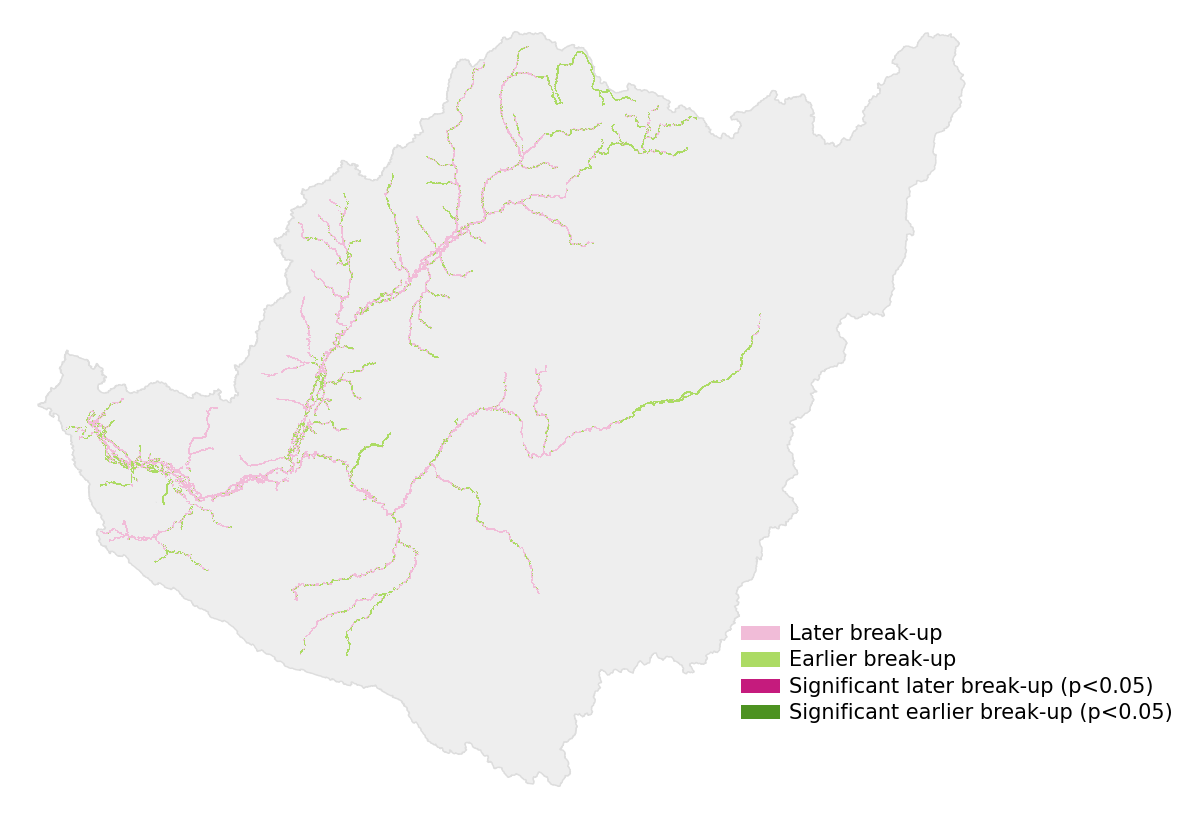

Saved trend rasters:
  /home/jovyan/FinalProject/analysis_ready/ice_phenology/breakup_trend/sen_slope_days_per_year.tif
  /home/jovyan/FinalProject/analysis_ready/ice_phenology/breakup_trend/mk_pvalue.tif
  /home/jovyan/FinalProject/analysis_ready/ice_phenology/breakup_trend/trend_class.tif
Saved PNG figure:
  /home/jovyan/FinalProject/analysis_ready/ice_phenology/images/breakup_trend.png
Freeze-up date trend
Input directory: /home/jovyan/FinalProject/analysis_ready/ice_phenology/freezeup_DOHY
Trend output directory: /home/jovyan/FinalProject/analysis_ready/ice_phenology/freezeup_trend
Found 2 yearly rasters: 2001–2002


Reading rasters:   0%|          | 0/2 [00:00<?, ?it/s]

Stack shape: (2, 625, 712) (years, rows, columns)


Computing pixel-wise trends:   0%|          | 0/445000 [00:00<?, ?it/s]

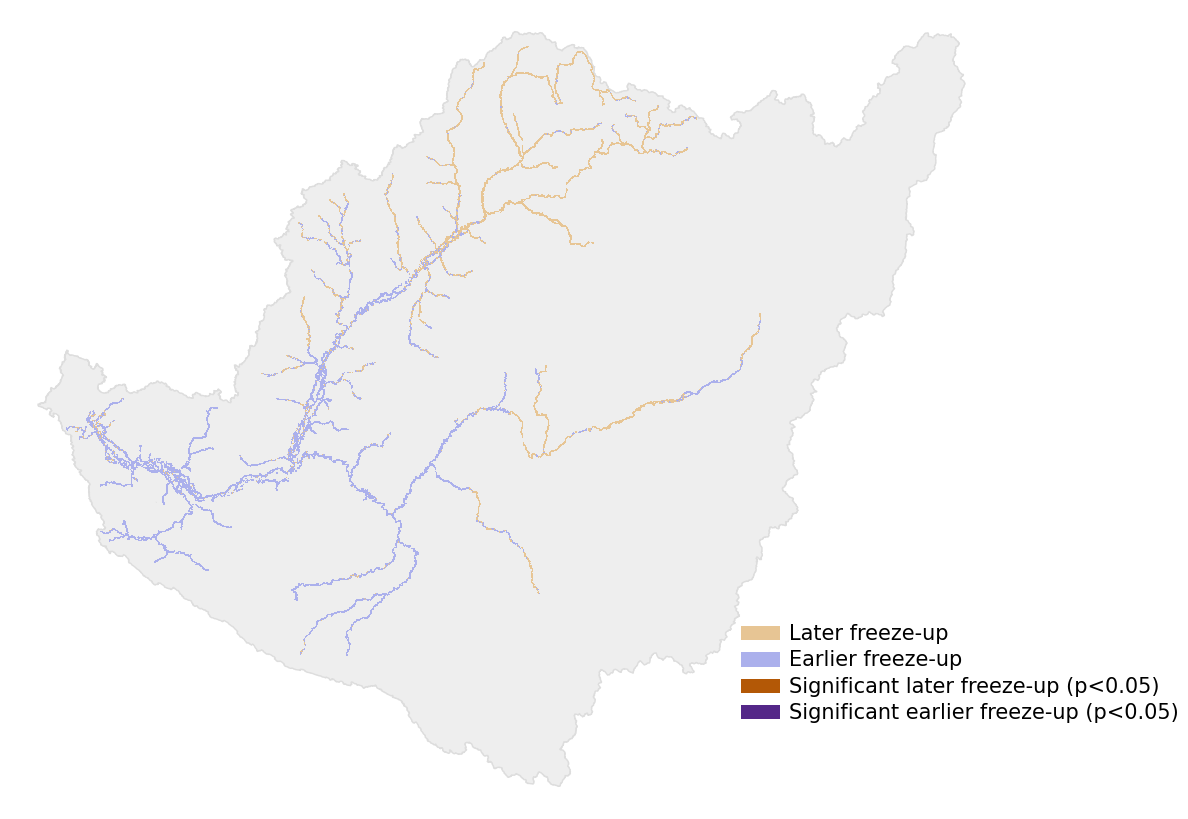

Saved trend rasters:
  /home/jovyan/FinalProject/analysis_ready/ice_phenology/freezeup_trend/sen_slope_days_per_year.tif
  /home/jovyan/FinalProject/analysis_ready/ice_phenology/freezeup_trend/mk_pvalue.tif
  /home/jovyan/FinalProject/analysis_ready/ice_phenology/freezeup_trend/trend_class.tif
Saved PNG figure:
  /home/jovyan/FinalProject/analysis_ready/ice_phenology/images/freezeup_trend.png
Ice duration trend
Input directory: /home/jovyan/FinalProject/analysis_ready/ice_phenology/ice_duration_DAY
Trend output directory: /home/jovyan/FinalProject/analysis_ready/ice_phenology/ice_duration_trend
Found 2 yearly rasters: 2001–2002


Reading rasters:   0%|          | 0/2 [00:00<?, ?it/s]

Stack shape: (2, 625, 712) (years, rows, columns)


Computing pixel-wise trends:   0%|          | 0/445000 [00:00<?, ?it/s]

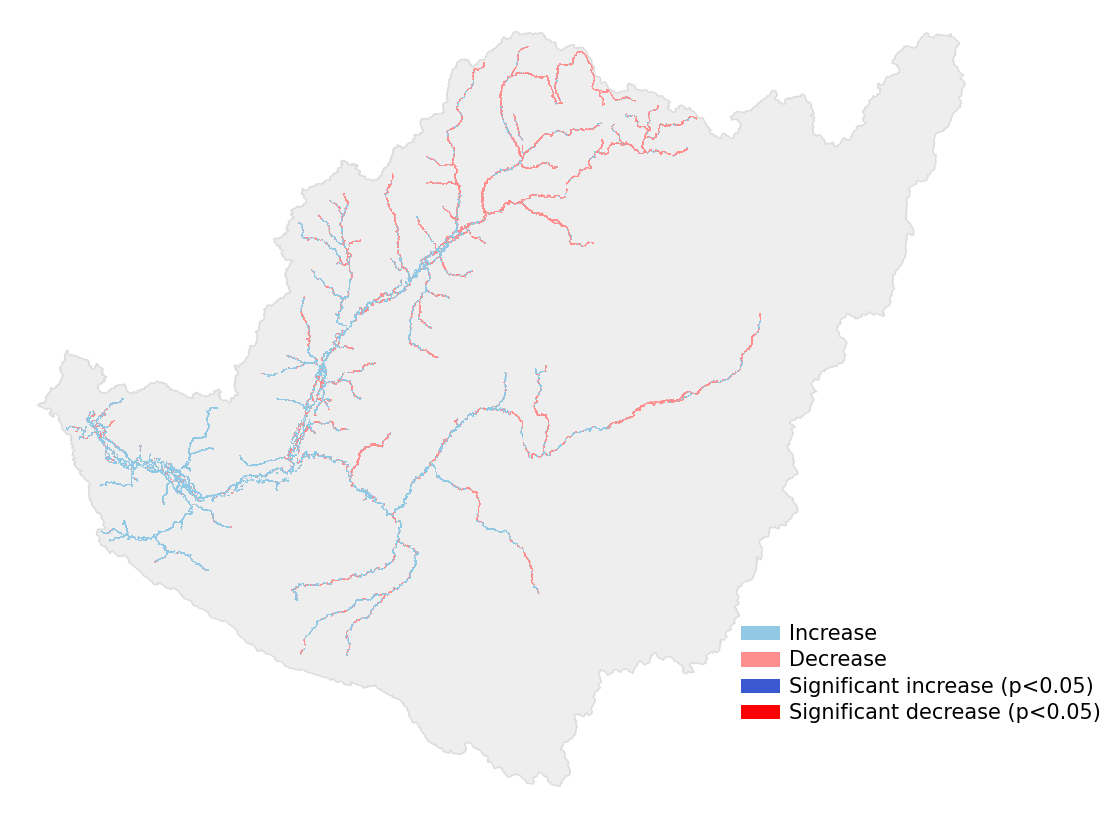

Saved trend rasters:
  /home/jovyan/FinalProject/analysis_ready/ice_phenology/ice_duration_trend/sen_slope_days_per_year.tif
  /home/jovyan/FinalProject/analysis_ready/ice_phenology/ice_duration_trend/mk_pvalue.tif
  /home/jovyan/FinalProject/analysis_ready/ice_phenology/ice_duration_trend/trend_class.tif
Saved PNG figure:
  /home/jovyan/FinalProject/analysis_ready/ice_phenology/images/ice_duration_trend.png


In [9]:
EXPORT_OPTIONAL_PDFS = False

results = []
for cfg in DATASETS:
    result = process_dataset(cfg, export_optional_pdfs=EXPORT_OPTIONAL_PDFS)
    results.append(result)

## Trend class summaries

The next cell prints a compact diagnostic summary of the mapped trend classes. This is useful for checking whether each output contains valid pixels and whether the signs of the trends are reasonable.

In [10]:
for result in results:
    cfg = result["config"]
    years = result["years"]
    summary = result["summary"]

    display(Markdown(f"### {cfg.title} ({years[0]}–{years[-1]})"))
    for key, value in summary.items():
        if key.endswith("_percent"):
            print(f"{key}: {value:.2f}%")
        else:
            print(f"{key}: {value}")
    print()

### Break-up date trend (2001–2002)

valid_pixels: 14153
nodata_pixels: 430847
significant_negative: 0
negative: 4914
zero: 503
positive: 8736
significant_positive: 0
significant_negative_percent: 0.00%
negative_percent: 34.72%
zero_percent: 3.55%
positive_percent: 61.73%
significant_positive_percent: 0.00%



### Freeze-up date trend (2001–2002)

valid_pixels: 13944
nodata_pixels: 431056
significant_negative: 0
negative: 8233
zero: 253
positive: 5458
significant_positive: 0
significant_negative_percent: 0.00%
negative_percent: 59.04%
zero_percent: 1.81%
positive_percent: 39.14%
significant_positive_percent: 0.00%



### Ice duration trend (2001–2002)

valid_pixels: 13841
nodata_pixels: 431159
significant_negative: 0
negative: 5826
zero: 112
positive: 7903
significant_positive: 0
significant_negative_percent: 0.00%
negative_percent: 42.09%
zero_percent: 0.81%
positive_percent: 57.10%
significant_positive_percent: 0.00%



## Display saved PNG figures

The following cell displays the PNG files saved in `FinalProject/analysis_ready/ice_phenology/images`.

### Break-up date trend (2001–2002)

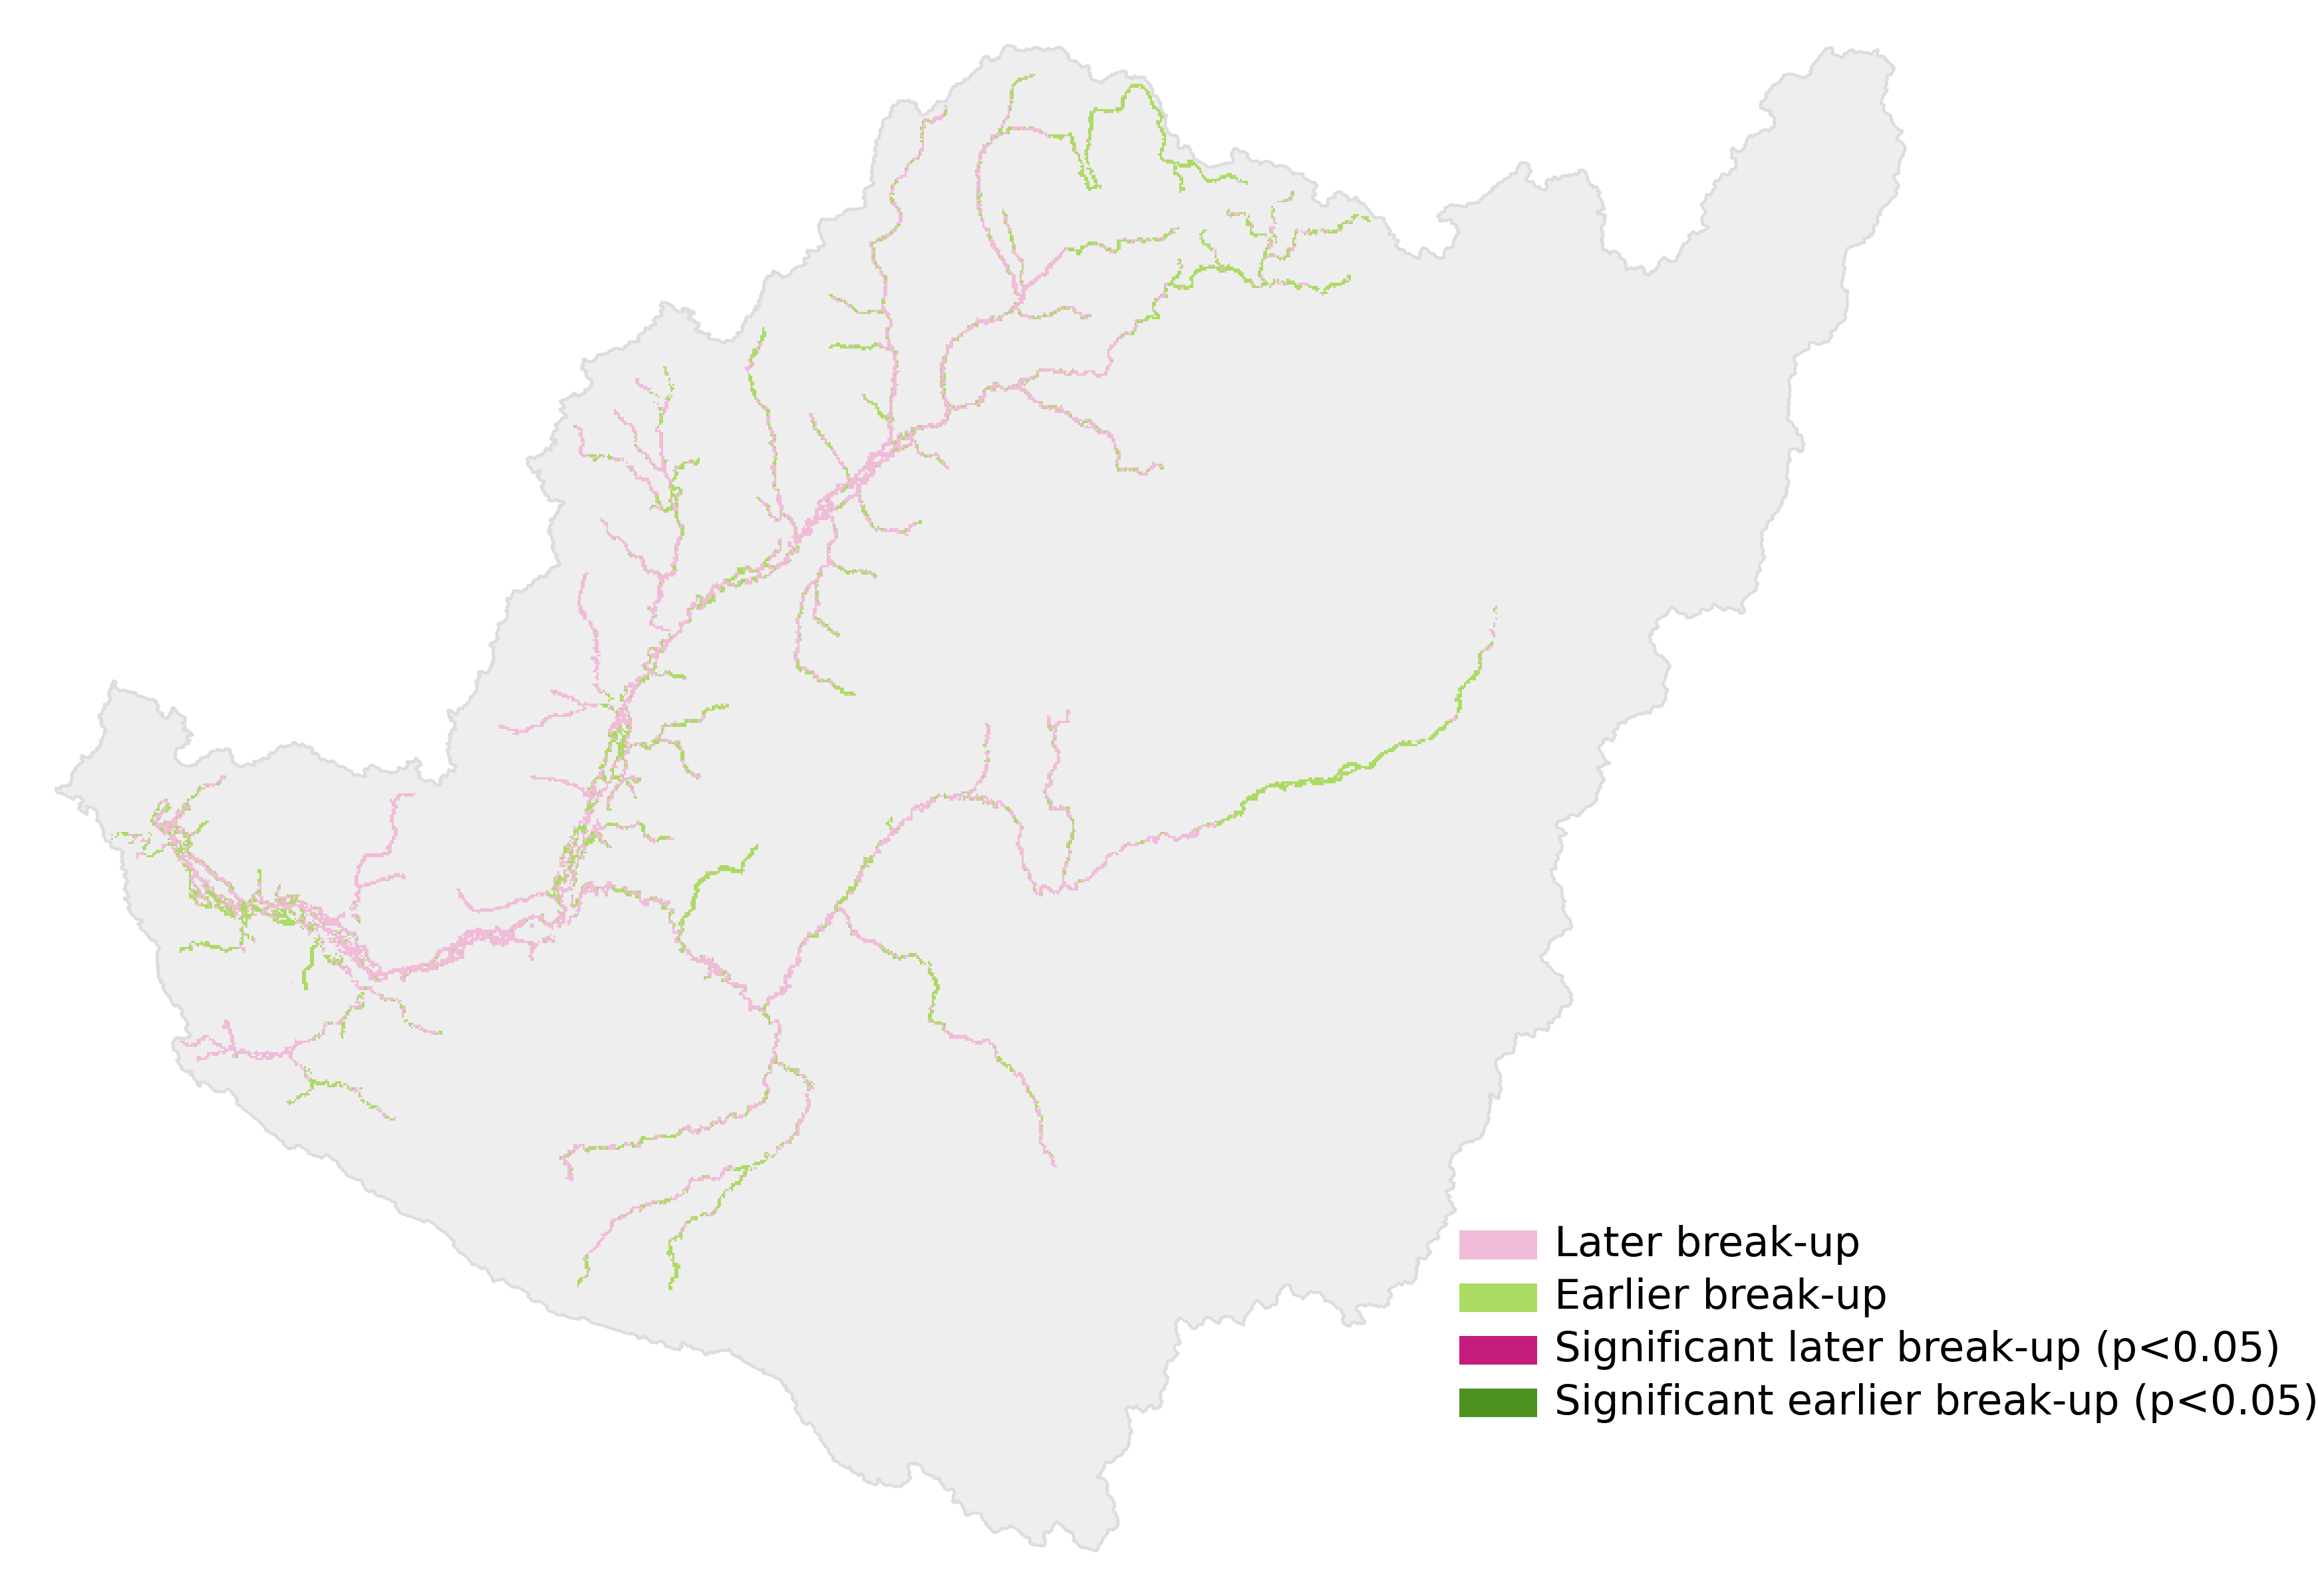

### Freeze-up date trend (2001–2002)

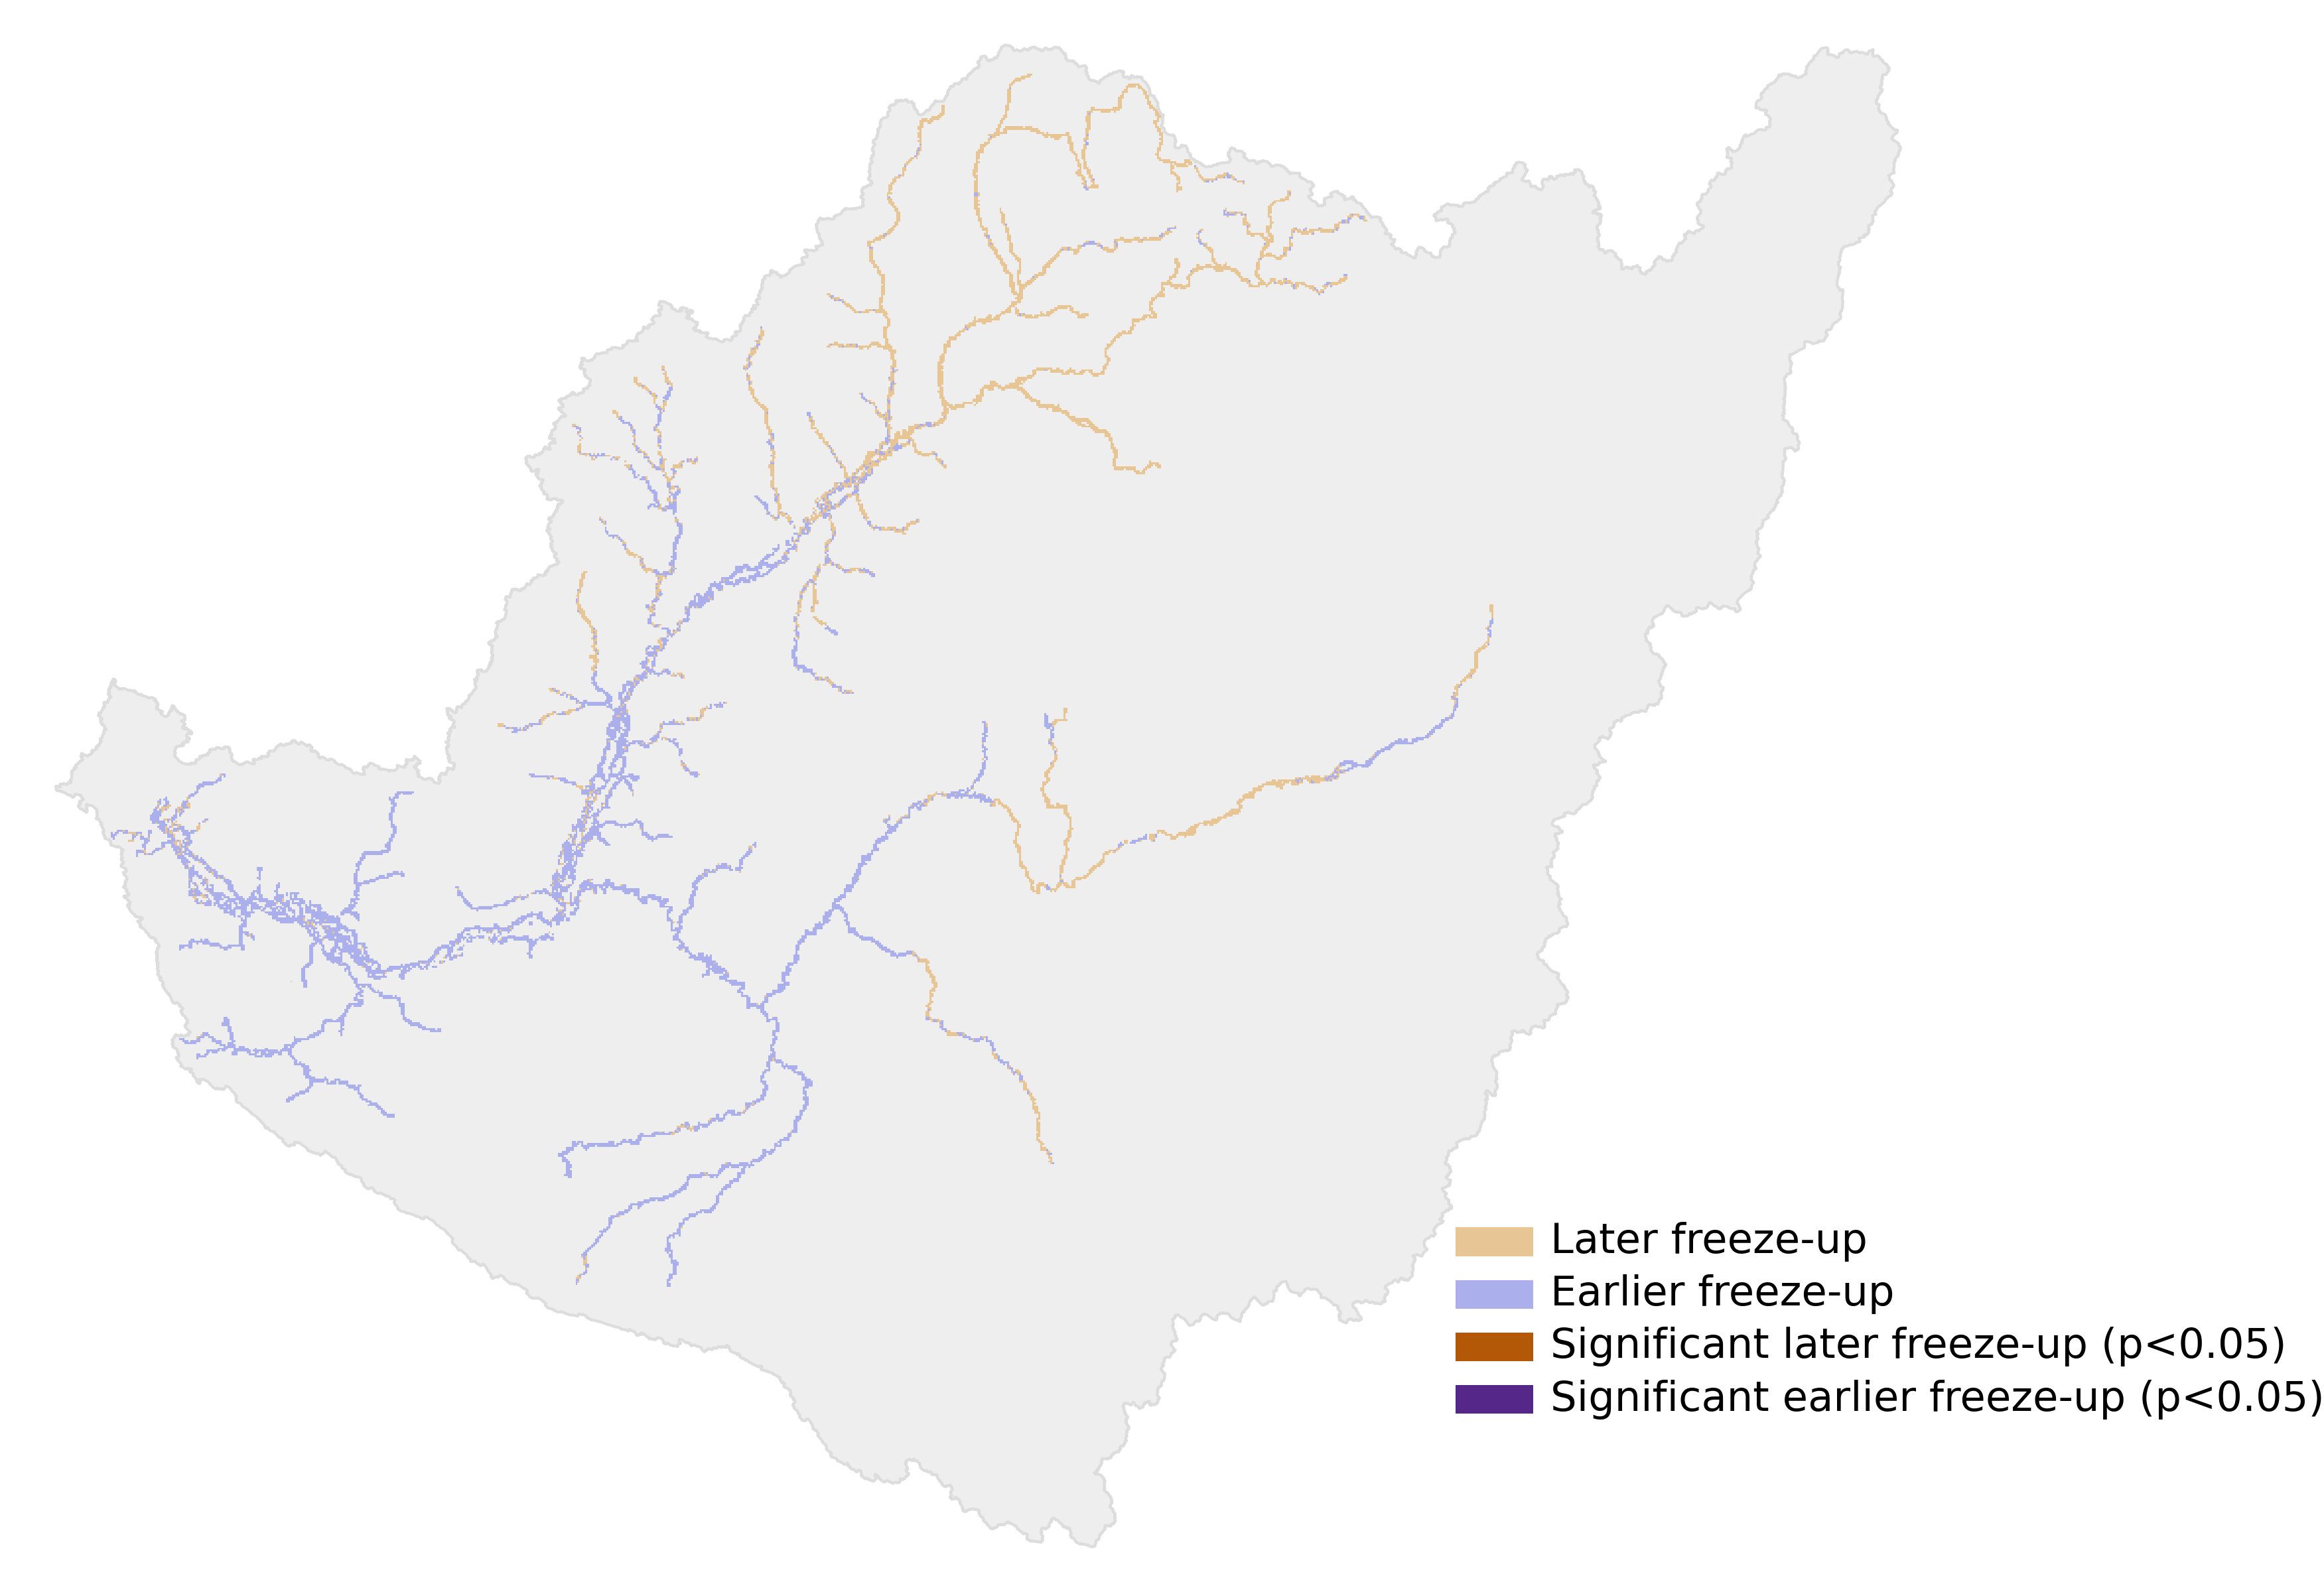

### Ice duration trend (2001–2002)

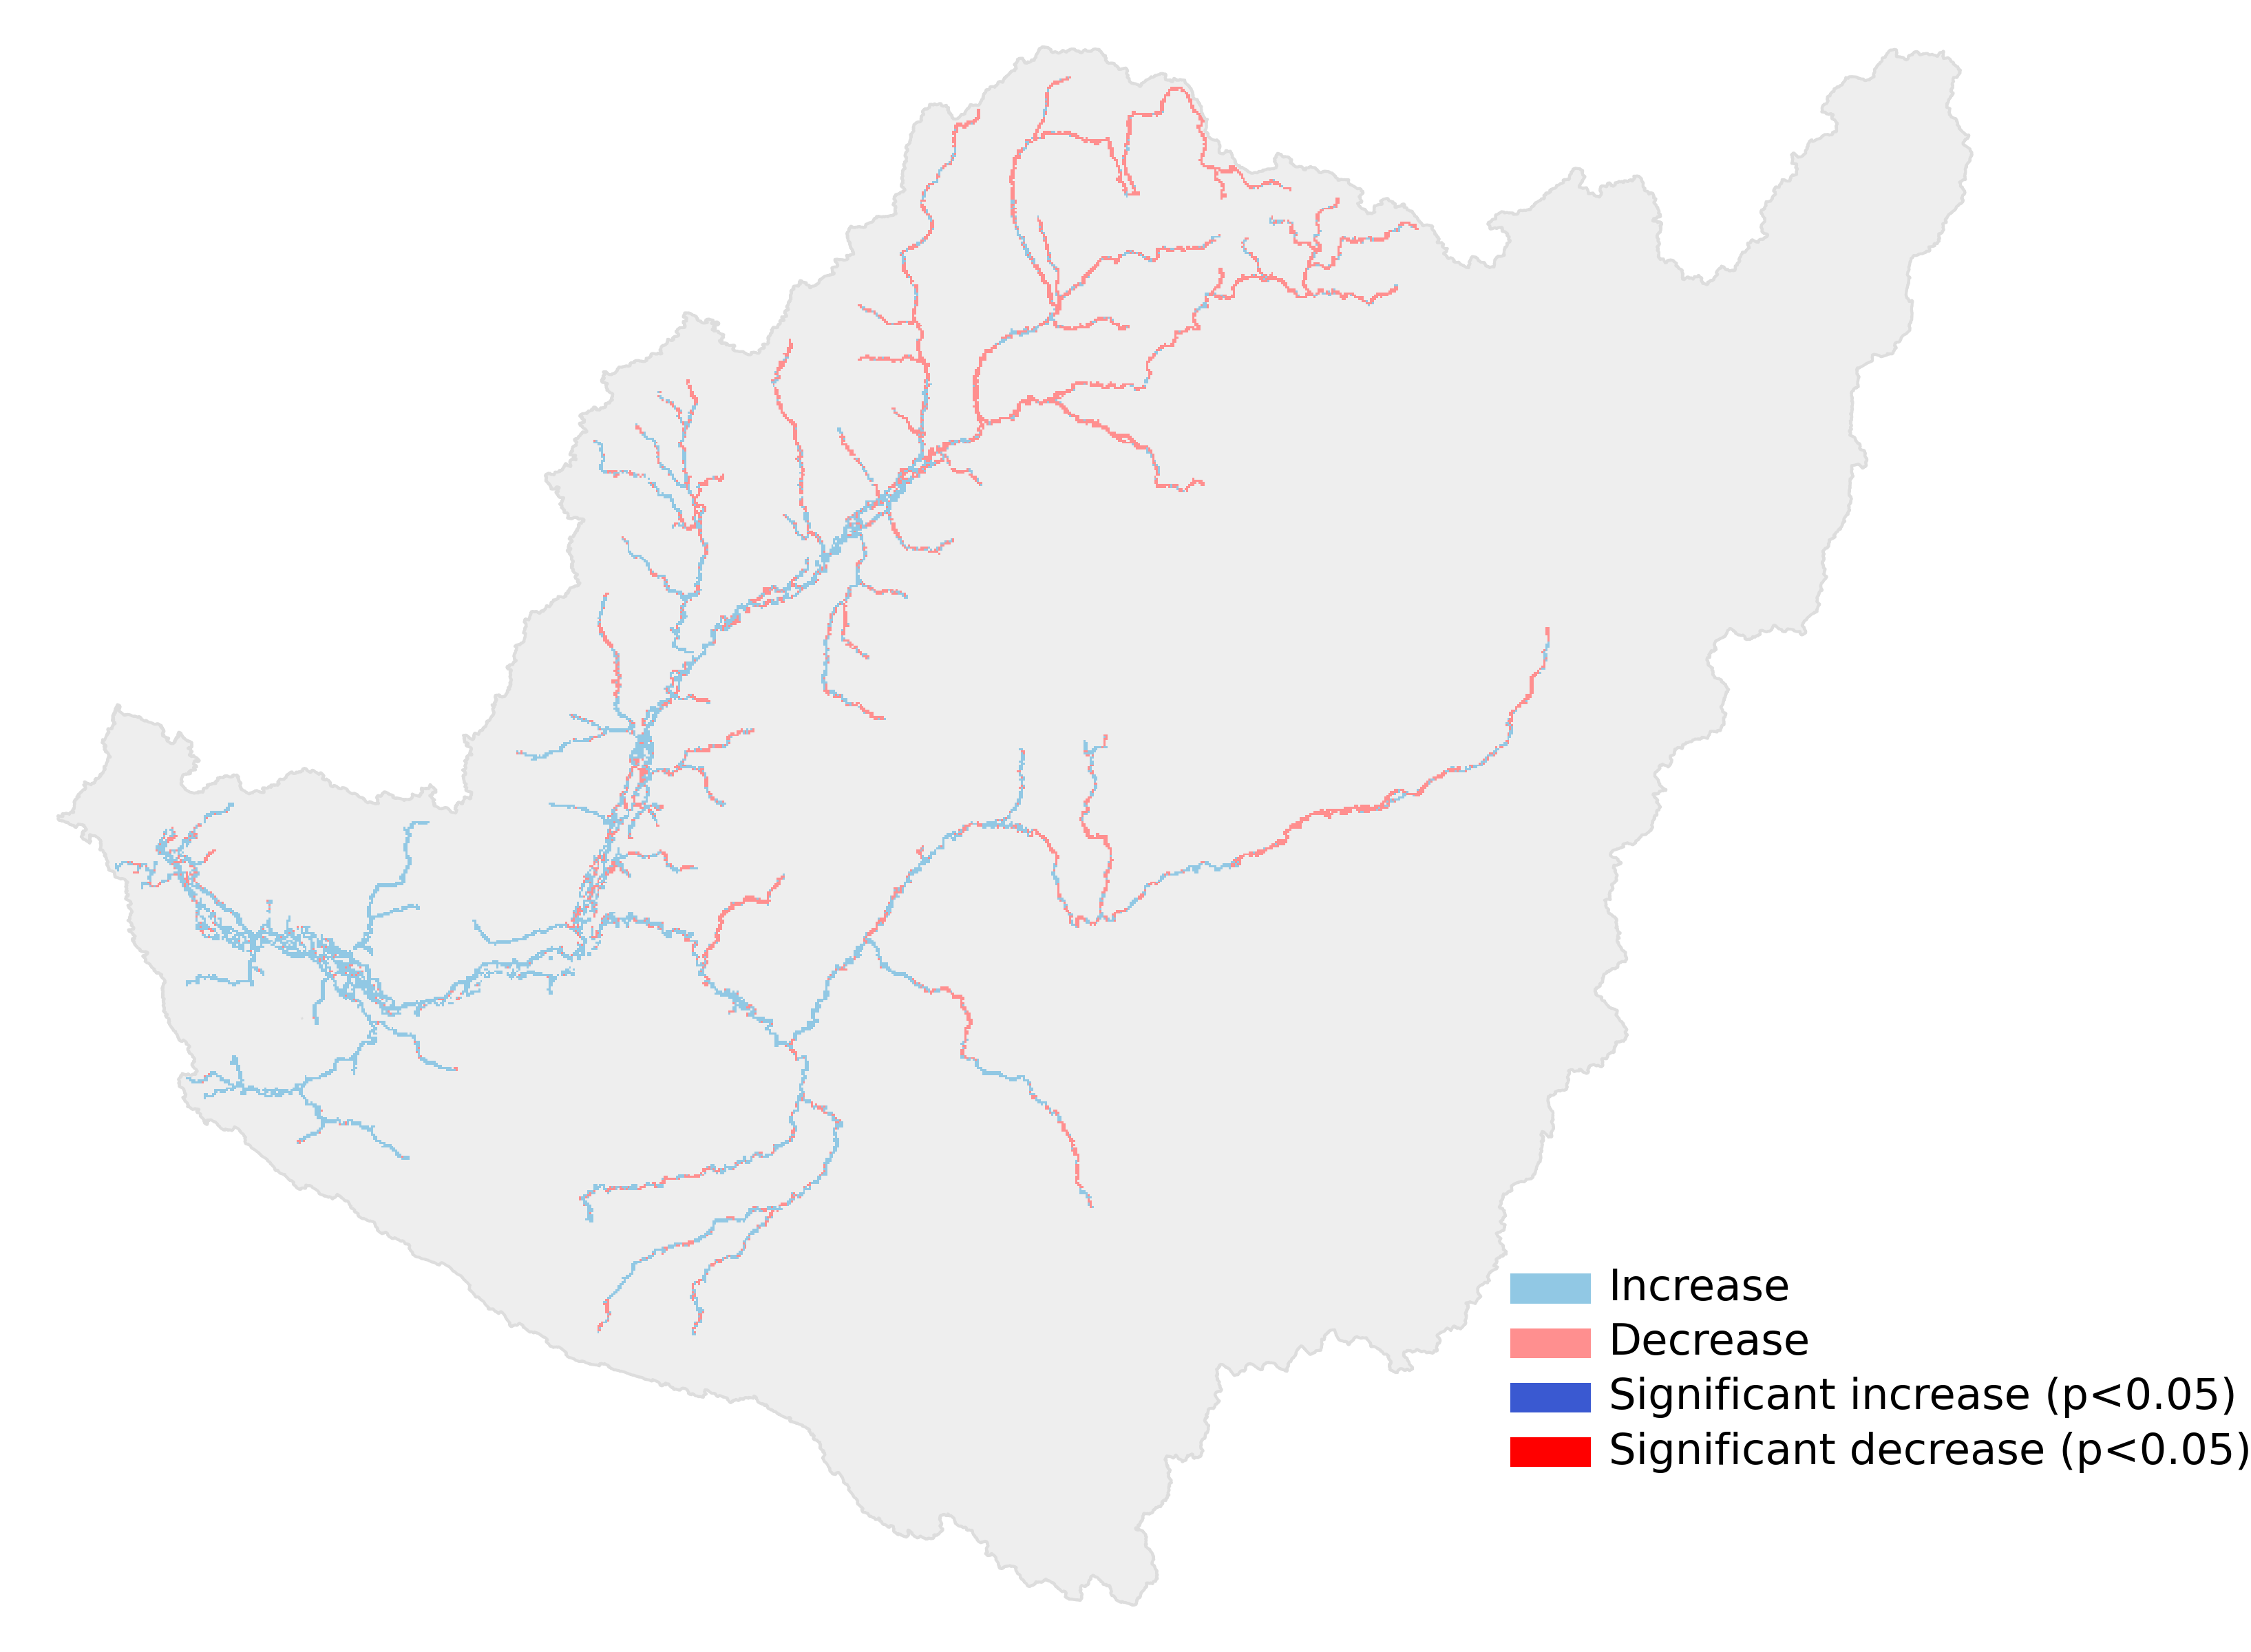

In [11]:
for result in results:
    cfg = result["config"]
    png_path = result["png_path"]
    years = result["years"]

    display(Markdown(f"### {cfg.title} ({years[0]}–{years[-1]})"))
    display(IPyImage(filename=str(png_path)))

## Figure captions

**Figure 1. Spatial pattern of interannual trends in river ice break-up date.**  
Green shades indicate earlier break-up, whereas pink shades indicate later break-up. Darker colors denote statistically significant monotonic trends at p < 0.05. Trends were estimated pixel-wise from annual break-up date rasters using Theil–Sen slope, with significance evaluated using Kendall tau p-values.

**Figure 2. Spatial pattern of interannual trends in river ice freeze-up date.**  
Purple shades indicate earlier freeze-up, whereas brown shades indicate later freeze-up. Darker colors denote statistically significant monotonic trends at p < 0.05. Trends were estimated pixel-wise from annual freeze-up date rasters using Theil–Sen slope, with significance evaluated using Kendall tau p-values.

**Figure 3. Spatial pattern of interannual trends in river ice duration.**  
Red shades indicate decreasing ice duration, whereas blue shades indicate increasing ice duration. Darker colors denote statistically significant monotonic trends at p < 0.05. Trends were estimated pixel-wise from annual ice-duration rasters using Theil–Sen slope, with significance evaluated using Kendall tau p-values.